In [21]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
sc.settings.verbosity = 3

# Instead of set_figure_params, configure matplotlib manually
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['savefig.dpi'] = 100


In [20]:
combined_unharm

AnnData object with n_obs × n_vars = 250000 × 50
    obs: 'total_counts', 'cell_type_level1', 'batch', 'batch_indices', 'cell_types'
    uns: 'batch_colors', 'log1p', 'neighbors', 'pca', 'umap'

In [2]:
from models.harmony import run_harmony_integration
from models.scanorama import run_scanorama_integration
from models.scVI_model import run_scvi_integration
from models.scETM import run_scetm_integration

In [3]:
%matplotlib inline

In [4]:
combined_data = sc.read_h5ad("combined_data_scVI.h5ad")
combined_data_scetm =sc.read_h5ad("combined_data_scVI_scetm.h5ad")

In [5]:
combined_data

AnnData object with n_obs × n_vars = 262104 × 5634
    obs: 'total_counts', 'cell_type_level1', 'batch', '_scvi_batch', '_scvi_labels'
    var: 'mean', 'std'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'batch_colors', 'cell_type_level1_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scanorama', 'X_scvi', 'X_tmp', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [6]:
combined_data

AnnData object with n_obs × n_vars = 262104 × 5634
    obs: 'total_counts', 'cell_type_level1', 'batch', '_scvi_batch', '_scvi_labels'
    var: 'mean', 'std'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'batch_colors', 'cell_type_level1_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scanorama', 'X_scvi', 'X_tmp', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [7]:
combined_data_scetm

AnnData object with n_obs × n_vars = 262104 × 50
    obs: 'total_counts', 'cell_type_level1', 'batch', 'batch_indices', 'cell_types', '_scvi_batch', '_scvi_labels'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'batch_colors', 'cell_type_level1_colors', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scanorama', 'X_scvi', 'X_umap'
    obsp: 'connectivities', 'distances'

In [6]:
# combined_data_pca = sc.read_h5ad("umaps_doc/combined_data_pca.h5ad")
# combined_data_sctem = sc.read_h5ad("obs_and_x_scetm.h5ad")

In [8]:
sc.pp.normalize_total(combined_data, target_sum=1e4)
sc.pp.log1p(combined_data)
sc.pp.scale(combined_data)
sc.pp.pca(combined_data,n_comps=50)

normalizing counts per cell
    finished (0:00:03)
computing PCA
    with n_comps=50
    finished (0:03:54)


In [9]:
combined_data.write_h5ad("combined_data_scVI.h5ad")

In [10]:
combined_data

AnnData object with n_obs × n_vars = 262104 × 5634
    obs: 'total_counts', 'cell_type_level1', 'batch', '_scvi_batch', '_scvi_labels'
    var: 'mean', 'std'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'batch_colors', 'cell_type_level1_colors', 'neighbors', 'pca', 'umap', 'log1p'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scanorama', 'X_scvi', 'X_tmp', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:59)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:04:09)


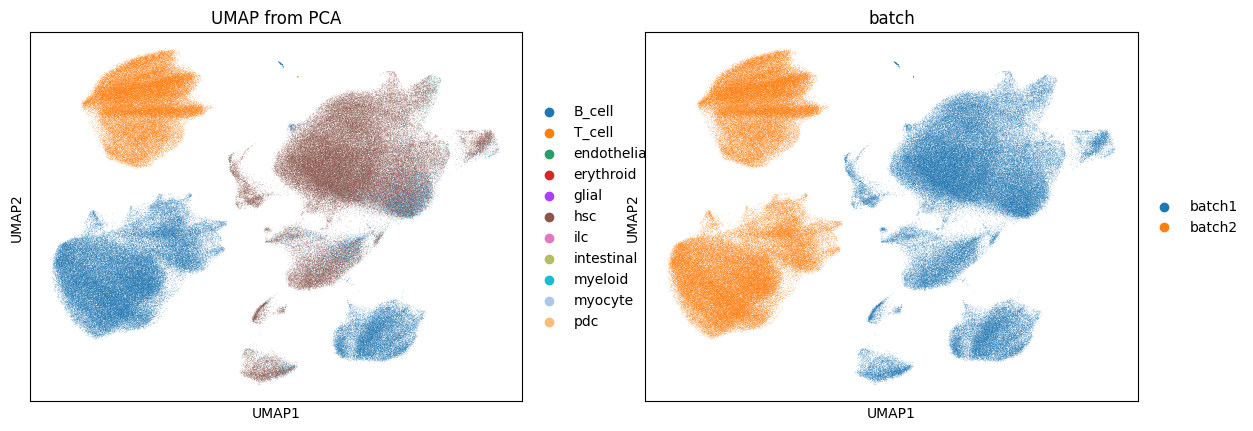

In [11]:
sc.pp.neighbors(combined_data, use_rep="X_pca")
sc.tl.umap(combined_data)
sc.pl.umap(combined_data, color=["cell_type_level1", "batch"], title="UMAP from PCA")

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:35)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:04:17)


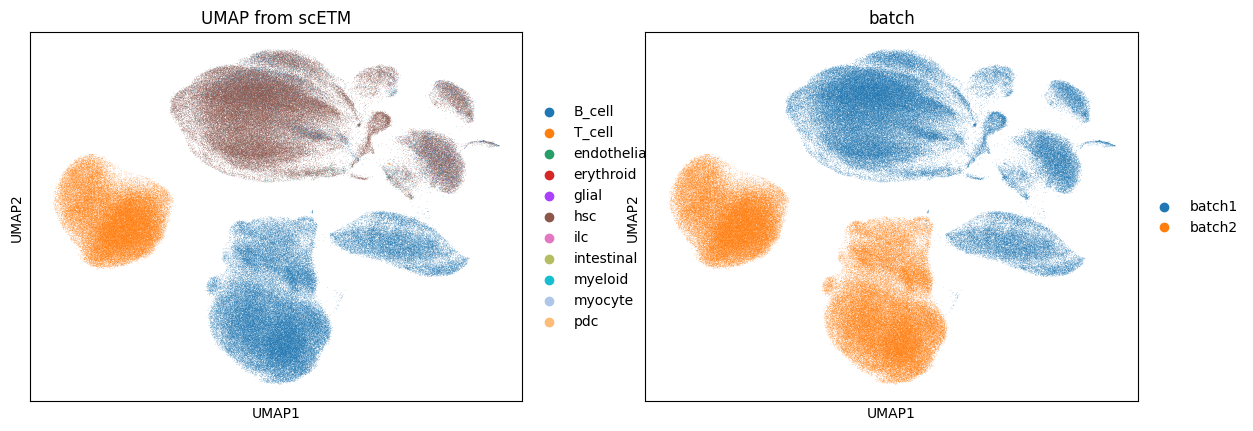

In [12]:
sc.pp.neighbors(combined_data_scetm, use_rep="X_pca")
sc.tl.umap(combined_data_scetm)
sc.pl.umap(combined_data_scetm, color=["cell_type_level1", "batch"], title="UMAP from scETM")

In [52]:
# sc.pp.neighbors(combined_data_pca)
# sc.tl.umap(combined_data_pca)
# sc.pl.umap(combined_data_pca, color=["batch","cell_type_level1"], title="Unharmonized",show=True)

In [53]:
# #sctem model umap (without any other methods)
# sc.pp.neighbors(combined_data_sctem)
# sc.tl.umap(combined_data_sctem)
# sc.pl.umap(combined_data_sctem, color=["batch","cell_type_level1"], title="scETM",show=True)

Harmony

In [ ]:
# combined_data_pca = combined_data_scVI.copy()

In [26]:
# sc.pp.pca(combined_data_pca,n_comps=50)

computing PCA
    with n_comps=50
    finished (0:00:45)


In [27]:
# combined_data_pca

AnnData object with n_obs × n_vars = 262104 × 5634
    obs: 'total_counts', 'cell_type_level1', 'batch', '_scvi_batch', '_scvi_labels'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'batch_colors', 'cell_type_level1_colors', 'neighbors', 'umap', 'pca'
    obsm: 'X_scanorama', 'X_scvi', 'X_umap', 'X_pca'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [28]:
# run_harmony_integration(combined_data_pca, batch_key='batch', theta=2, max_iter_harmony=20)

2025-10-01 12:11:02,801 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-01 12:11:57,341 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-01 12:11:58,594 - harmonypy - INFO - Iteration 1 of 20
2025-10-01 12:14:04,875 - harmonypy - INFO - Iteration 2 of 20
2025-10-01 12:16:24,984 - harmonypy - INFO - Iteration 3 of 20
2025-10-01 12:18:27,509 - harmonypy - INFO - Iteration 4 of 20
2025-10-01 12:20:33,592 - harmonypy - INFO - Converged after 4 iterations


array([[-47.63269   , -14.871863  , -14.869653  , ...,  -1.1679076 ,
         -1.5121045 ,  -2.7771566 ],
       [-40.41379   , -27.795345  , -11.289167  , ...,   2.109473  ,
          0.27697602,   2.9200451 ],
       [-49.726715  ,  -9.490574  , -24.653944  , ...,   0.42898232,
          1.6937304 ,   1.8128595 ],
       ...,
       [-52.141396  , -15.688312  ,   3.4009266 , ...,  -0.9815304 ,
         -0.71439093,  -0.48998442],
       [-50.24441   , -15.593731  ,   3.4244888 , ...,   1.8297658 ,
          3.2561266 ,  -2.3220975 ],
       [-57.721653  , -17.387047  ,   2.61533   , ...,  -1.4550433 ,
         -2.1497166 ,  -4.0113745 ]], shape=(262104, 50), dtype=float32)

In [ ]:
# combined_data_pca.write_h5ad("combined_data_scVI.h5ad")

In [30]:
# combined_data_pca

AnnData object with n_obs × n_vars = 262104 × 5634
    obs: 'total_counts', 'cell_type_level1', 'batch', '_scvi_batch', '_scvi_labels'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'batch_colors', 'cell_type_level1_colors', 'neighbors', 'umap', 'pca'
    obsm: 'X_scanorama', 'X_scvi', 'X_umap', 'X_pca', 'X_pca_harmony'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:37)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:04:03)


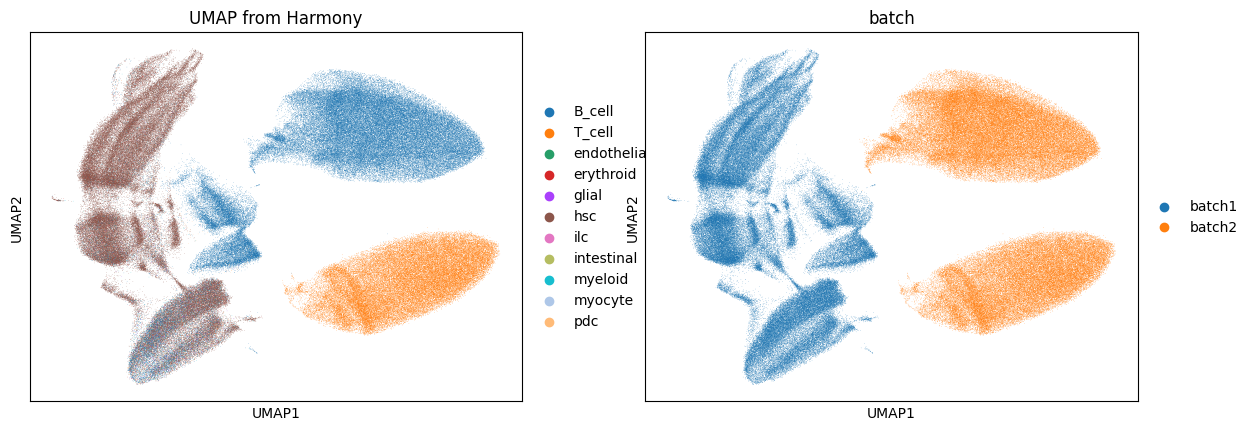

In [13]:
sc.pp.neighbors(combined_data, use_rep="X_pca_harmony")
sc.tl.umap(combined_data)
sc.pl.umap(combined_data, color=["cell_type_level1", "batch"], title="UMAP from Harmony")

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:37)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:04:08)


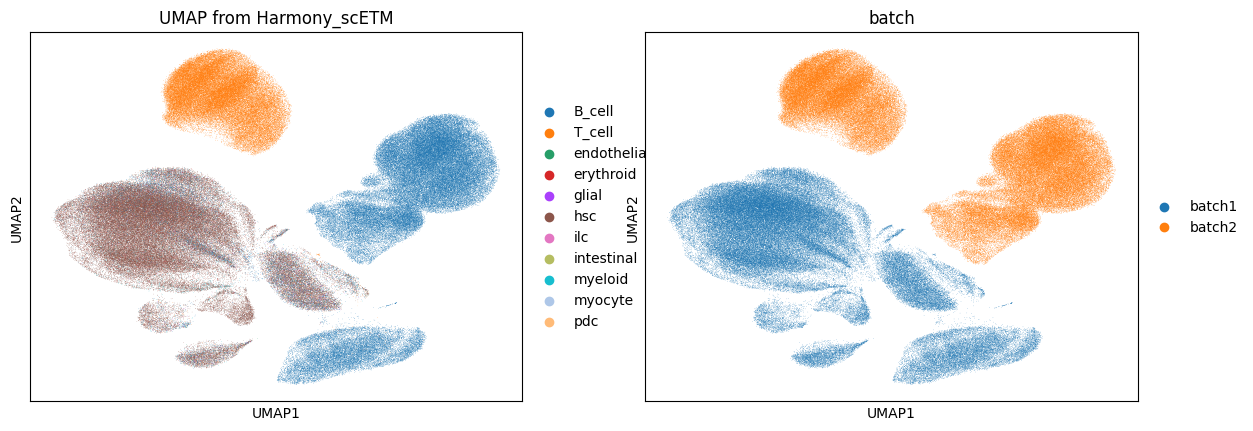

In [14]:
sc.pp.neighbors(combined_data_scetm, use_rep="X_pca_harmony")
sc.tl.umap(combined_data_scetm)
sc.pl.umap(combined_data_scetm, color=["cell_type_level1", "batch"], title="UMAP from Harmony_scETM")

In [ ]:
# sc.pp.neighbors(combined_data_pca,use_rep='X_pca_harmony')
# sc.tl.umap(combined_data_pca)
# sc.pl.umap(combined_data_pca, color=["batch","cell_type_level1"], title="Harmony",show=True)

In [ ]:
# combined_data_sctem = combined_data_scVI_scetm.copy()

In [32]:
# combined_data_sctem

AnnData object with n_obs × n_vars = 262104 × 50
    obs: 'total_counts', 'cell_type_level1', 'batch', 'batch_indices', 'cell_types', '_scvi_batch', '_scvi_labels'
    uns: '_scvi_manager_uuid', '_scvi_uuid'
    obsm: 'X_scanorama', 'X_scvi'

In [ ]:
# combined_data_sctem.obsm['X_pca'] = combined_data_sctem.X

In [34]:
# run_harmony_integration(combined_data_sctem, batch_key='batch', theta=2, max_iter_harmony=20)

2025-10-01 12:21:00,000 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-01 12:21:49,145 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-01 12:21:50,877 - harmonypy - INFO - Iteration 1 of 20
2025-10-01 12:24:05,624 - harmonypy - INFO - Iteration 2 of 20
2025-10-01 12:25:03,179 - harmonypy - INFO - Iteration 3 of 20
2025-10-01 12:25:47,540 - harmonypy - INFO - Converged after 3 iterations


array([[0.01691822, 0.02655741, 0.02454649, ..., 0.02821524, 0.01987326,
        0.02591558],
       [0.01483957, 0.0191588 , 0.01280142, ..., 0.02195393, 0.01824553,
        0.02033687],
       [0.01604777, 0.02522762, 0.023621  , ..., 0.02542502, 0.03153532,
        0.02993577],
       ...,
       [0.02623349, 0.0423032 , 0.03576879, ..., 0.06464212, 0.03411498,
        0.05462162],
       [0.03641011, 0.03817986, 0.03990548, ..., 0.06267966, 0.03452038,
        0.05362655],
       [0.02991719, 0.03781357, 0.03529958, ..., 0.05636219, 0.03271683,
        0.05405477]], shape=(262104, 50), dtype=float32)

In [35]:
# combined_data_sctem

AnnData object with n_obs × n_vars = 262104 × 50
    obs: 'total_counts', 'cell_type_level1', 'batch', 'batch_indices', 'cell_types', '_scvi_batch', '_scvi_labels'
    uns: '_scvi_manager_uuid', '_scvi_uuid'
    obsm: 'X_scanorama', 'X_scvi', 'X_pca', 'X_pca_harmony'

In [ ]:
# combined_data_sctem.write_h5ad("combined_data_scVI_scetm.h5ad")

In [ ]:

# sc.pp.neighbors(combined_data_sctem,use_rep='X_pca_harmony')
# sc.tl.umap(combined_data_sctem)
# sc.pl.umap(combined_data_sctem, color=["batch","cell_type_level1"], title="Harmony_scETM",show=True)

scVI

In [ ]:
# combined_data_scar = sc.read_h5ad("umaps_doc/disease_parse_unharmonized.h5ad")

In [ ]:
# run_scvi_integration(combined_data_scar, batch_key="batch", max_epochs=200, early_stopping=True, use_gpu=True)

In [ ]:
# combined_data_scar.write_h5ad("combined_data_scVI.h5ad")

In [ ]:
# combined_data_scar = sc.read("combined_data_scVI.h5ad")

In [ ]:
# sc.pp.neighbors(combined_data_scar,use_rep='X_scvi')
# sc.tl.umap(combined_data_scar)
# sc.pl.umap(combined_data_scar, color=["batch","cell_type_level1"], title="scVI",show=True)

In [ ]:
# run_scvi_integration(combined_data_sctem, batch_key="batch", max_epochs=200, early_stopping=True, use_gpu=True)

In [ ]:
# combined_data_sctem.write_h5ad("combined_data_scVI_scetm.h5ad")

In [ ]:
# combined_data_scetm = sc.read("combined_data_scVI_scetm.h5ad")

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:31)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:04:02)


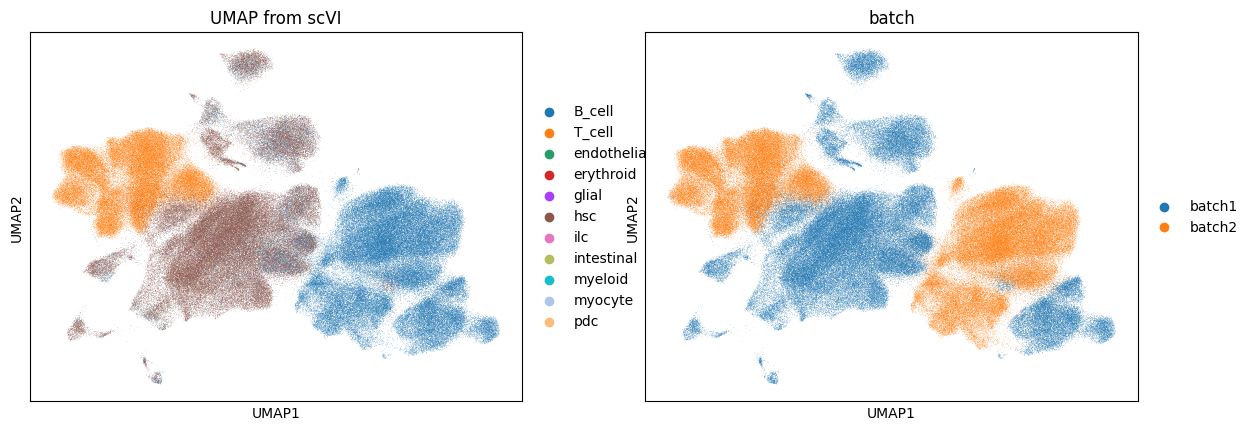

In [15]:
sc.pp.neighbors(combined_data, use_rep="X_scvi")
sc.tl.umap(combined_data)
sc.pl.umap(combined_data, color=["cell_type_level1", "batch"], title="UMAP from scVI")

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:34)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:03:57)


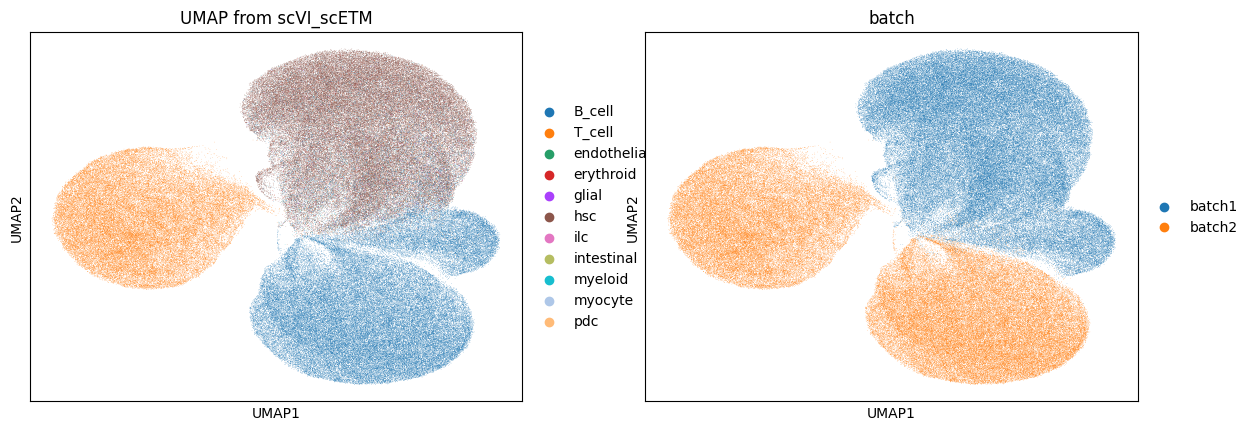

In [17]:
sc.pp.neighbors(combined_data_scetm, use_rep="X_scvi")
sc.tl.umap(combined_data_scetm)
sc.pl.umap(combined_data_scetm, color=["cell_type_level1", "batch"], title="UMAP from scVI_scETM")

In [16]:
# sc.pp.neighbors(combined_data_sctem,use_rep='X_scvi')
# sc.tl.umap(combined_data_sctem)
# sc.pl.umap(combined_data_sctem, color=["batch","cell_type_level1"], title="scVI_scETM",show=True)


Scaranoma

In [ ]:
# import anndata as ad

# combined_data_scar  = combined_data_scVI.copy()

In [ ]:
# combined_data_scar

AnnData object with n_obs × n_vars = 262104 × 5634
    obs: 'total_counts', 'cell_type_level1', 'batch', '_scvi_batch', '_scvi_labels'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'batch_colors', 'cell_type_level1_colors', 'neighbors', 'umap'
    obsm: 'X_scvi', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
# combined_data_scar.obsm['X_scanorama']=run_scanorama_integration(combined_data_scar,batch_key='batch')

Found 5634 genes among all datasets
[[0.         0.00407472]
 [0.         0.        ]]


In [ ]:
# combined_data_scar

AnnData object with n_obs × n_vars = 262104 × 5634
    obs: 'total_counts', 'cell_type_level1', 'batch', '_scvi_batch', '_scvi_labels'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'batch_colors', 'cell_type_level1_colors', 'neighbors', 'umap'
    obsm: 'X_scvi', 'X_umap', 'X_scanorama'
    obsp: 'connectivities', 'distances'

In [ ]:
# combined_data_scar.write_h5ad("combined_data_scVI.h5ad")

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:40)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:04:18)


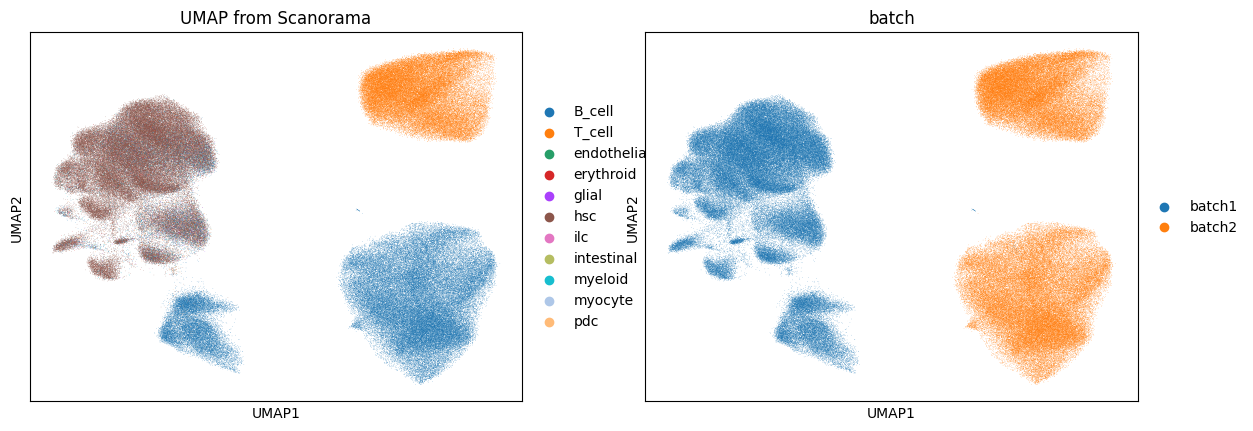

In [18]:
sc.pp.neighbors(combined_data, use_rep="X_scanorama")
sc.tl.umap(combined_data)
sc.pl.umap(combined_data, color=["cell_type_level1", "batch"], title="UMAP from Scanorama")

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:38)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:04:07)


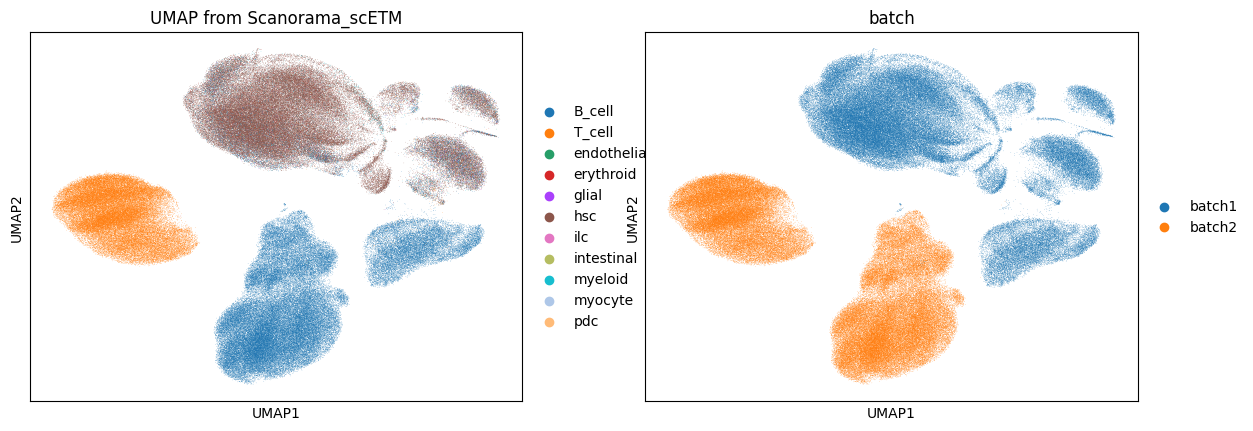

In [19]:
sc.pp.neighbors(combined_data_scetm, use_rep="X_scanorama")
sc.tl.umap(combined_data_scetm)
sc.pl.umap(combined_data_scetm, color=["cell_type_level1", "batch"], title="UMAP from Scanorama_scETM")

In [ ]:
# sc.pp.neighbors(combined_data_scar,use_rep='X_scanorama')
# sc.tl.umap(combined_data_scar)
# sc.pl.umap(combined_data_scar, color=["batch","cell_type_level1"], title="Scanorama",show=True)


In [ ]:
# combined_data_sctem  = combined_data_scVI_scetm.copy()

In [ ]:
# combined_data_scVI_scetm

AnnData object with n_obs × n_vars = 262104 × 50
    obs: 'total_counts', 'cell_type_level1', 'batch', 'batch_indices', 'cell_types', '_scvi_batch', '_scvi_labels'
    uns: '_scvi_manager_uuid', '_scvi_uuid'
    obsm: 'X_scvi'

In [ ]:
# combined_data_sctem.obsm['X_scanorama']=run_scanorama_integration(combined_data_sctem,batch_key='batch')

Found 50 genes among all datasets
[[0.         0.02975155]
 [0.         0.        ]]


In [ ]:
# combined_data_sctem

AnnData object with n_obs × n_vars = 262104 × 50
    obs: 'total_counts', 'cell_type_level1', 'batch', 'batch_indices', 'cell_types', '_scvi_batch', '_scvi_labels'
    uns: '_scvi_manager_uuid', '_scvi_uuid'
    obsm: 'X_scvi', 'X_scanorama'

In [ ]:
# combined_data_sctem.write_h5ad("combined_data_scVI_scetm.h5ad")

In [ ]:
# sc.pp.neighbors(combined_data_sctem,use_rep='X_scanorama')
# sc.tl.umap(combined_data_sctem)
# sc.pl.umap(combined_data_sctem, color=["batch","cell_type_level1"], title="Scanorama_scETM",show=True)

Harmonized

In [8]:
combined_data_har = sc.read_h5ad("umaps_doc/disease_parse_harmonized.h5ad")


In [9]:
combined_data_har

AnnData object with n_obs × n_vars = 262104 × 5634
    obs: 'total_counts', 'cell_type_level1', 'batch'

In [10]:
# Example mapping
mapping = {
    "B_cell": "B_cell",
    "b_cell": "B_cell",
    "T_cell": "T_cell",
    "t_cell": "T_cell"
    # add others if needed
}

combined_data_har.obs["cell_type_level1"] = combined_data_har.obs["cell_type_level1"].replace(mapping)


In [11]:
sc.pp.normalize_total(combined_data_har, target_sum=1e4)
sc.pp.log1p(combined_data_har)
sc.pp.scale(combined_data_har)
sc.pp.pca(combined_data_har,n_comps=50)

normalizing counts per cell
    finished (0:00:01)
computing PCA
    with n_comps=50
    finished (0:04:19)


computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:38)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:04:06)


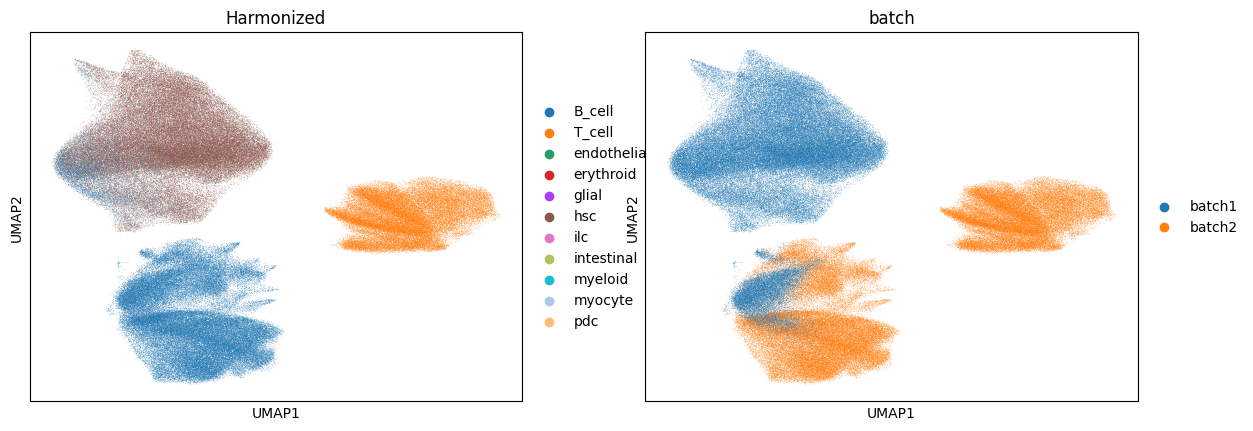

In [13]:
sc.pp.neighbors(combined_data_har,use_rep='X_pca')
sc.tl.umap(combined_data_har)
sc.pl.umap(combined_data_har, color=["cell_type_level1","batch"], title="Harmonized",show=True)

In [ ]:
# combined_data_sctem.write_h5ad("combined_data_scVI_scetm.h5ad")